In [1]:
# !pip install koreanize-matplotlib
import koreanize_matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)  # 열 개수 제한 없음
pd.set_option('display.max_rows', None)  # 행 개수 제한 없음

# 바론과 케니의 매개효과 분석
- 첫번째 변수 X가 두번째 변수 M에 영향을 미치고, 이어서 M 변수가 세번째 변수 Y에 영향을 미치는 **연쇄적인 영향관계를 검정**
- M : **매개변수** 또는 **간접효과**

1. 총효과모델 (M이 없고, X와 Y만 존재)
    - c : 총효과 
    - X가 Y에 미치는 효과
2. 매개효과모델 (M : 매개변수가 있음)
    - $c{\prime}$ : 직접효과
    - 매개변수 M을 통제했을 때 X가 Y에 미치는 효과
    - 간접효과 a, b
    - a : X -> M
    - b : M -> Y
- **c = $c{\prime}$ + ab** : 총효과 = 직접효과 + 간접효과 
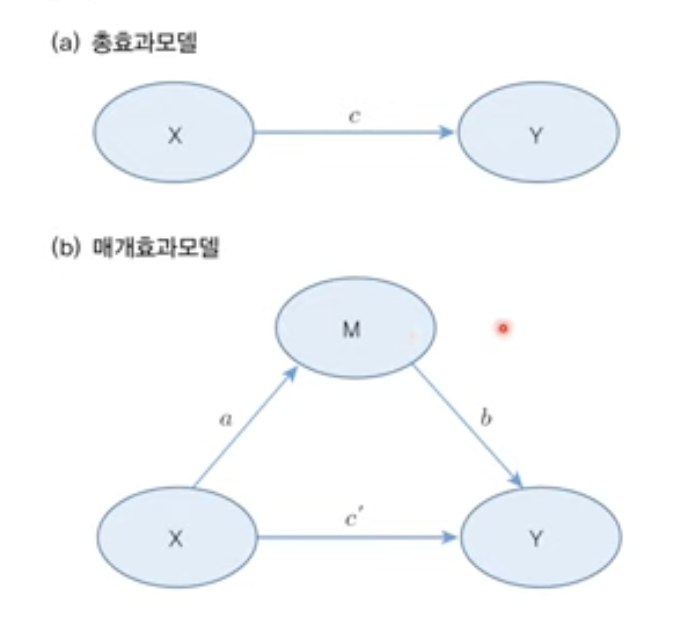
---
- Step 1: 독립변수(X) → 종속변수(Y) 영향 확인
- Step 2: 독립변수(X) → 매개변수(M) 영향 확인
- Step 3: 매개변수(M)와 독립변수(X)를 동시에 넣고 종속변수(Y) 예측
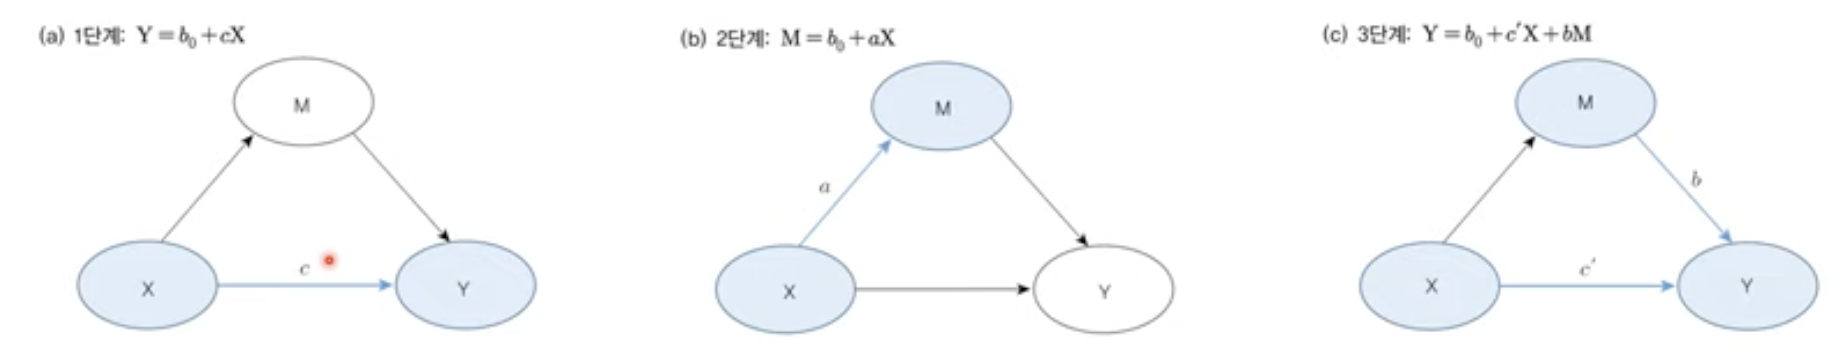

	매개효과 존재 조건:
	•	M이 Y에 유의미한 영향을 줘야 함 (b가 유의)  
	•	$c{\prime}$는 c보다 작아야 함. (X의 효과가 줄어야 매개효과가 있다고 볼 수 있어)  
	•	$c{\prime}$가 유의하지 않으면 완전 매개(full mediation).  
	•	$c{\prime}$가 여전히 유의하면 부분 매개(partial mediation).  
    
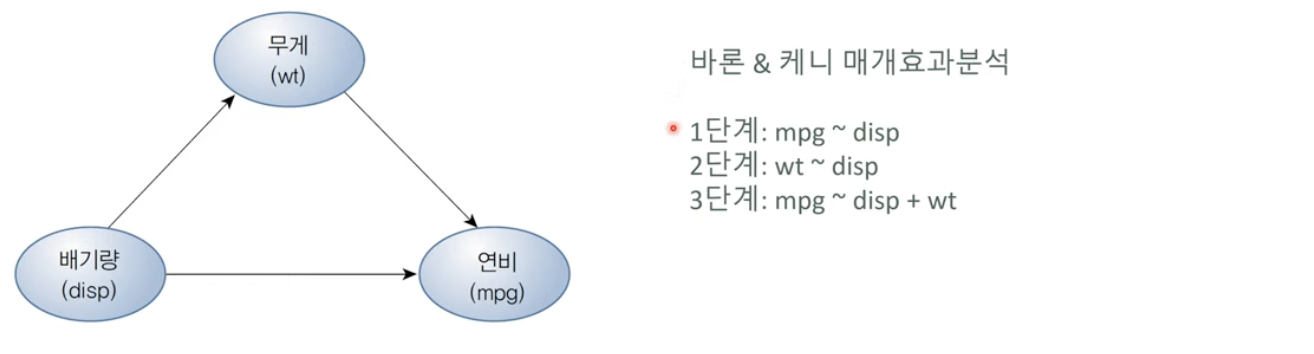

In [2]:
import statsmodels.api as sm

# mtcars 데이터 불러오기
mtcars = sm.datasets.get_rdataset("mtcars", package="datasets").data

mtcars.head()

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
rownames,,,,,,,,,,,
Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


In [4]:
import statsmodels.formula.api as smf
# Step1 : X -> Y 영향 확인 : 총효과 모델 확인
# 선형회귀모형 적합
model_total = smf.ols("mpg ~ disp", data=mtcars).fit()

# 결과 요약 출력
print(model_total.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.718
Model:                            OLS   Adj. R-squared:                  0.709
Method:                 Least Squares   F-statistic:                     76.51
Date:                Sun, 07 Sep 2025   Prob (F-statistic):           9.38e-10
Time:                        17:31:02   Log-Likelihood:                -82.105
No. Observations:                  32   AIC:                             168.2
Df Residuals:                      30   BIC:                             171.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     29.5999      1.230     24.070      0.0

In [6]:
# 유의수준 0.05에서 독립변수 disp의 유의확률이 매우 작으므로 귀무가설을 기각하여
# 배기량이 연비에 유의하게 영향을 미친다고 할 수 있다. 
# Step 1 만족

In [7]:
# Step2 : 독립변수와 매개변수간의 관계 확인 X -> M
model_M = smf.ols("wt ~ disp", data=mtcars).fit()
# 결과 요약 출력
print(model_M.summary())

                            OLS Regression Results                            
Dep. Variable:                     wt   R-squared:                       0.789
Model:                            OLS   Adj. R-squared:                  0.781
Method:                 Least Squares   F-statistic:                     111.8
Date:                Sun, 07 Sep 2025   Prob (F-statistic):           1.22e-11
Time:                        17:34:09   Log-Likelihood:                -19.344
No. Observations:                  32   AIC:                             42.69
Df Residuals:                      30   BIC:                             45.62
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.5998      0.173      9.248      0.0

In [8]:
# 독립변수 disp는 유의수준 0.05 하에서 귀무가설을 기각하므로 배기량이 매개변수 wt 배기량에 
# 유의한 영향을 미친다고 볼 수 있다.
# Step2 만족

In [11]:
# Step3 : 독립변수와 매개변수가 종속변수에 미치는 영향 확인
model_Y = smf.ols("mpg ~ disp + wt", data=mtcars).fit()
# 결과 요약 출력
print(model_Y.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.781
Model:                            OLS   Adj. R-squared:                  0.766
Method:                 Least Squares   F-statistic:                     51.69
Date:                Sun, 07 Sep 2025   Prob (F-statistic):           2.74e-10
Time:                        17:45:39   Log-Likelihood:                -78.084
No. Observations:                  32   AIC:                             162.2
Df Residuals:                      29   BIC:                             166.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     34.9606      2.165     16.151      0.0

In [12]:
# 무게(wt)는 유의수준 0.05에서 통계적으로 유의하다. (0.007) 
# 반면에 배기량(disp)는 유의수준 0.05에서 통게적으로 유의하지 않다. (0.064)

- 3단계에서 매개효과 모델에서 배기량과 연비간의 직접효과는 유의하지 않다. 하지만 1단계에서는 배기량과 연비간의 관계는 유의했다. 
- 1단계에서 총효과가 존재했던 반면,3단계에서 매개변수의 투입으로 배기량과 연비간의 직접효과가 사라졌다고 볼 수 있다.
- 따라서 자동차의 무게(wt)가 배기량과 연비간의 관계를 완전매개한다고 볼 수 있다.  

In [15]:
# 간접효과 계산 a*b
# 2단계의 회귀계수(X->W)와 3단계의 회귀계수(W->Y)를 곱하면 된다. 
a = model_M.params["disp"]
sa = model_M.bse["disp"]

# Step 2: M, X → Y (wt, disp → mpg)
b = model_Y.params["wt"]
sb = model_Y.bse["wt"]
a*b

-0.023490375689958005

- 바론과 케니 방법은 매개효과의 통계적 유의성 검정을 하지는 못함.
- 총효과모델에서 배기량과 연비간의 유의한 영향관계가 있음에도 불구하고, 매개효과모델에서 배기량과 연비간의 직접효과가 사라지는 영향변화가 통계적으로 유의한지는 알 수 없다.  
**=> 소벨 검정**
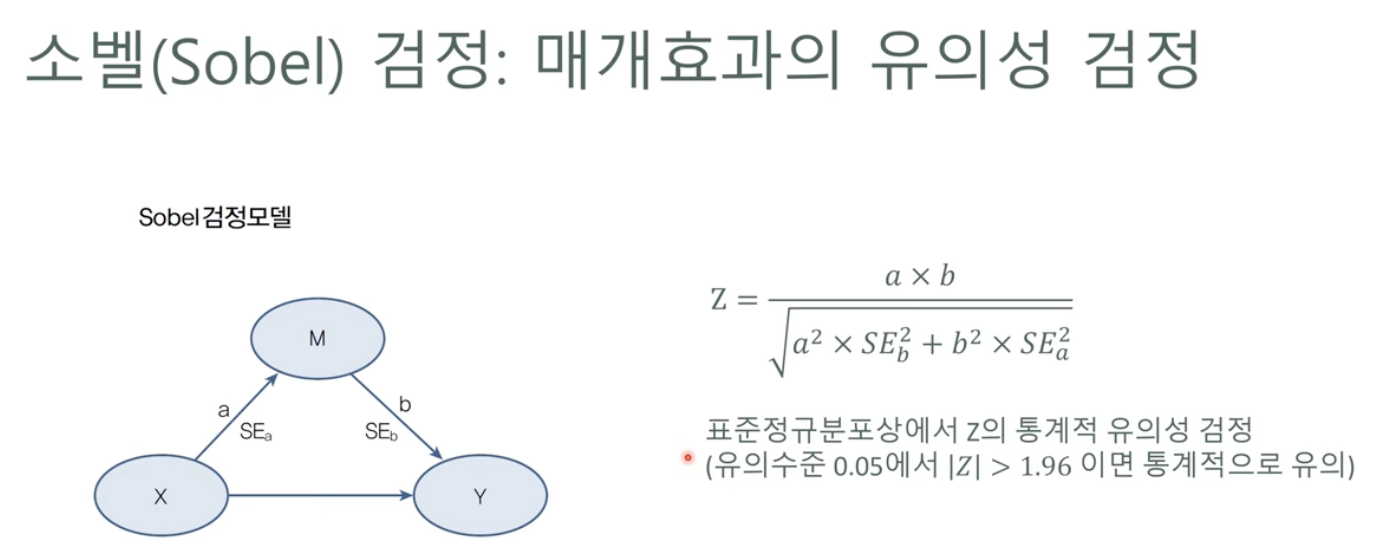

In [16]:
# Sobel test statistic
sobel_num = a * b
sobel_se = np.sqrt(b**2 * sa**2 + a**2 * sb**2)
z_value = sobel_num / sobel_se

print("a (disp→wt):", a)
print("b (wt→mpg controlling disp):", b)
print("Sobel z-value:", z_value)

a (disp→wt): 0.007010325323786809
b (wt→mpg controlling disp): -3.350825333348306
Sobel z-value: -2.7773707440794415


In [19]:
from scipy.stats import norm

# 이미 구한 z_value 사용
p_value = 2 * (1 - norm.cdf(abs(z_value)))

print("Sobel z-value:", z_value)
print("p-value:", p_value)

# 유의수준 0.05에서 귀무가설을 기각하여 매개효과가 유의하게 존재한다고 할 수 있다.

Sobel z-value: -2.7773707440794415
p-value: 0.005480063146107161


In [21]:
import pingouin as pg

med_result = pg.mediation_analysis(data=mtcars,
                                   x='disp',
                                   m='wt',
                                   y='mpg',
                                   alpha=0.05)
med_result

,path,coef,se,pval,CI[2.5%],CI[97.5%],sig
0,wt ~ X,0.007010,0.000663,1.222320e-11,0.005657,0.008364,Yes
1,Y ~ wt,-5.344472,0.559101,1.293959e-10,-6.486308,-4.202635,Yes
2,Total,-0.041215,0.004712,9.380327e-10,-0.050838,-0.031592,Yes
3,Direct,-0.017725,0.009190,6.361981e-02,-0.036521,0.001072,No
4,Indirect,-0.023490,0.008141,4.000000e-03,-0.038223,-0.006632,Yes


In [20]:
# Total : 유의함 -> 총 효과 유의하게 존재
# Direct : 유의하지 않음 -> 직접효과 유의하지 않음
# Indirect : 유의함 -> 간접효과(매개효과) 유의하게 존재
# 완전매개함

# 조절효과분석
- 변수 X와 Y간 관계에 대해서 제 3의 변수 Z의 영향을 검정
- Z: 조절 변수 
- 조절변수는 두 변수(X,Y)간의 관계를 강화시킬수도, 약화시킬수도 있음, 관계의 방향을 바꿀수도 있음
- 조절효과 = 상호작용효과
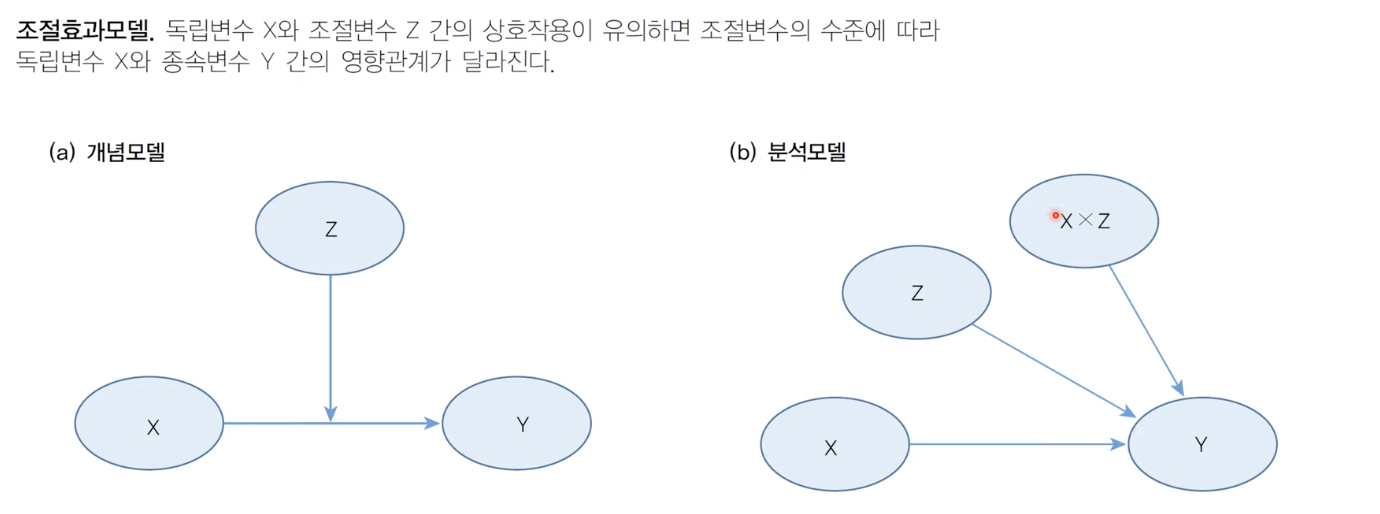
- X*Z 항이 Y에 미치는 영향이 유의한지를 확인

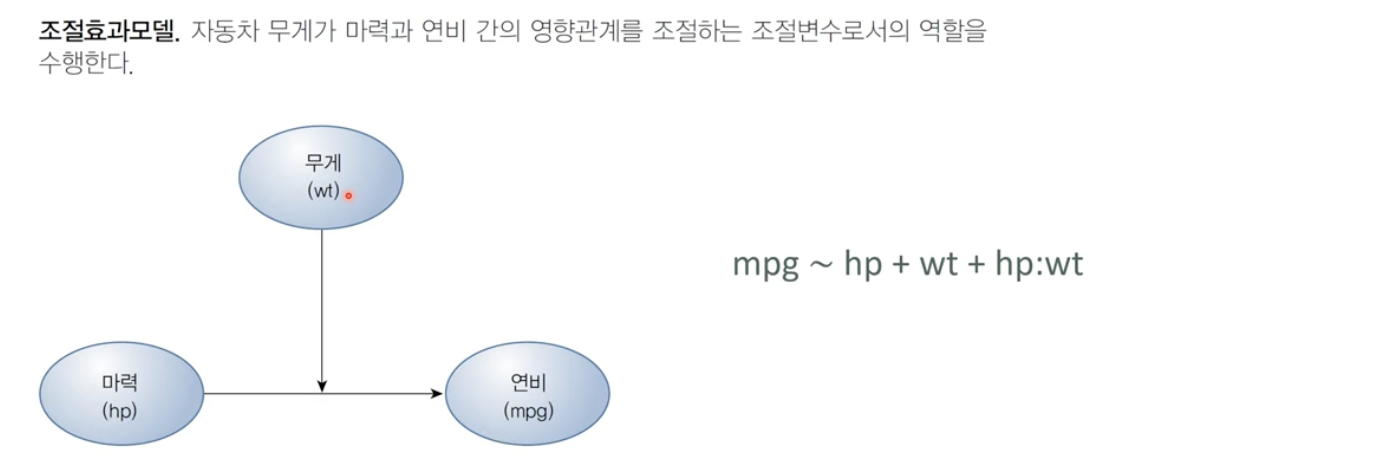

In [22]:
import statsmodels.api as sm

# mtcars 데이터 불러오기
mtcars = sm.datasets.get_rdataset("mtcars", package="datasets").data

mtcars.head()

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
rownames,,,,,,,,,,,
Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


In [25]:
import statsmodels.formula.api as smf
# Step1 : X -> Y 영향 확인 : 총효과 모델 확인
# 선형회귀모형 적합
model = smf.ols("mpg ~ hp + wt + hp:wt", data=mtcars).fit()

# 결과 요약 출력
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.885
Model:                            OLS   Adj. R-squared:                  0.872
Method:                 Least Squares   F-statistic:                     71.66
Date:                Sun, 07 Sep 2025   Prob (F-statistic):           2.98e-13
Time:                        18:08:04   Log-Likelihood:                -67.805
No. Observations:                  32   AIC:                             143.6
Df Residuals:                      28   BIC:                             149.5
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     49.8084      3.605     13.816      0.0

In [26]:
# 상호작용항이 유의수준 0.05에서 유의하다. 
# 즉, 연비와 마력간의 패턴은 무게에 따라 달라진다고 말할 수 있다.

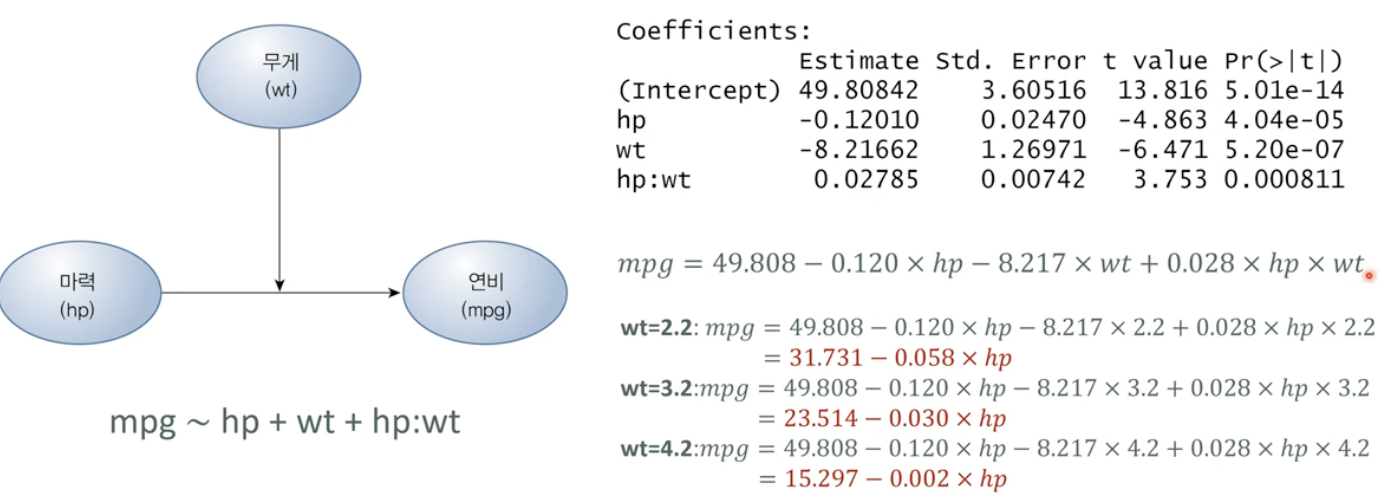

- 무게가 커짐에 따라서 마력 한단위의 증가가 연비의 감소에 미치는 영향은 점점 감소되는 것을 확인할 수 있다.
- 즉, 마력과 연비의 패턴은 무게에 따라서 변동된다는 조절효과를 확인할 수 있다.

In [29]:
# 시각화

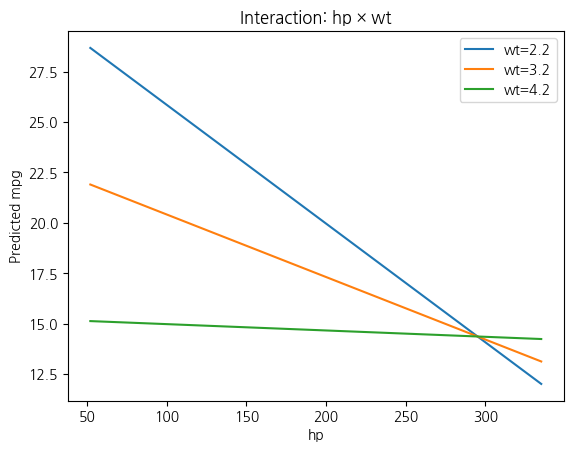

In [30]:
# wt 수준(평균 ± sd)과 hp 범위
m, s = mtcars["wt"].mean(), mtcars["wt"].std()
wt_levels = [round(m-s,1), round(m,1), round(m+s,1)]
hp_grid = np.linspace(mtcars.hp.min(), mtcars.hp.max(), 100)

# 예측 및 플롯
for wt in wt_levels:
    preds = model.get_prediction(pd.DataFrame({"hp": hp_grid, "wt": wt}))
    plt.plot(hp_grid, preds.predicted_mean, label=f"wt={wt}")
plt.xlabel("hp"); plt.ylabel("Predicted mpg")
plt.title("Interaction: hp × wt"); plt.legend(); plt.show()

- 무게가 증가함에 따라 hp가 mpg에 미치는 영향력이 줄어드는 것을 볼수 있다. 
- 심지어 wt가 가장 큰 녹색선을 보면 거의 수평선임을 알 수 있다. hp가 아무리 늘어남에도 mpg에 변동이 없음을 알 수 있다.

# 조절매개효과분석 
- 매개변수에 의해 매개된 두 변수 X,Y 간에 제 4의 변수(조절변수)가 영향을 미치는 지 검정
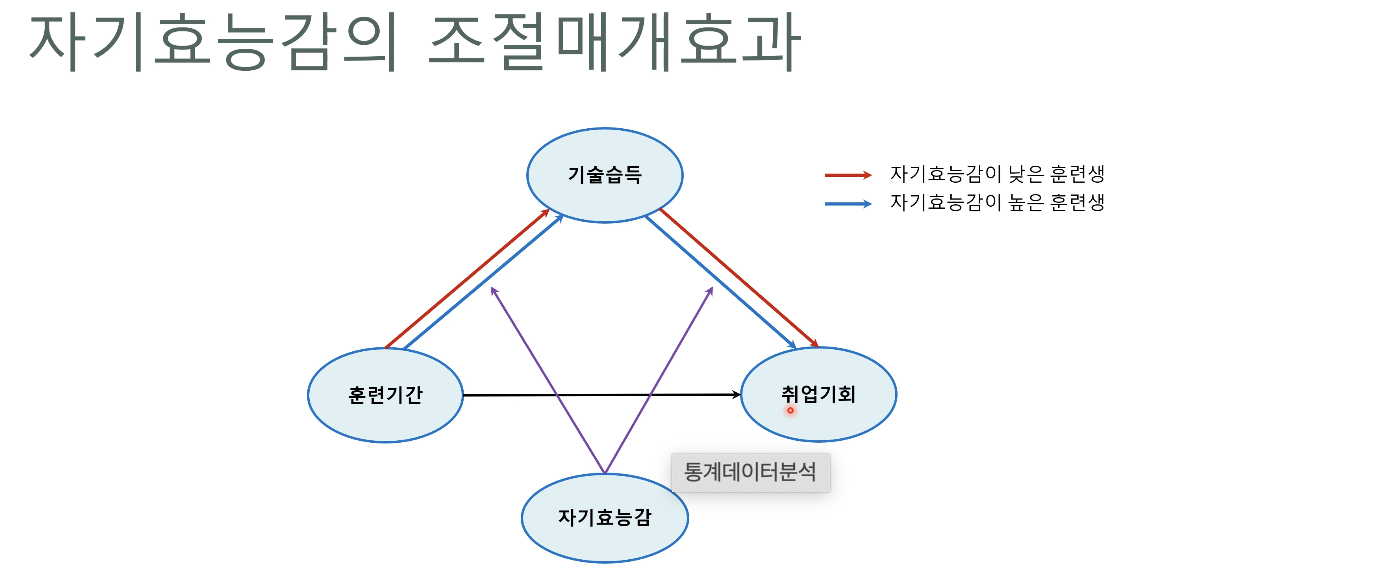
- X : 훈련기간 
- Y : 취업기회
- M : 기술습득 (매개변수)
- 조절변수 : 자기효능감

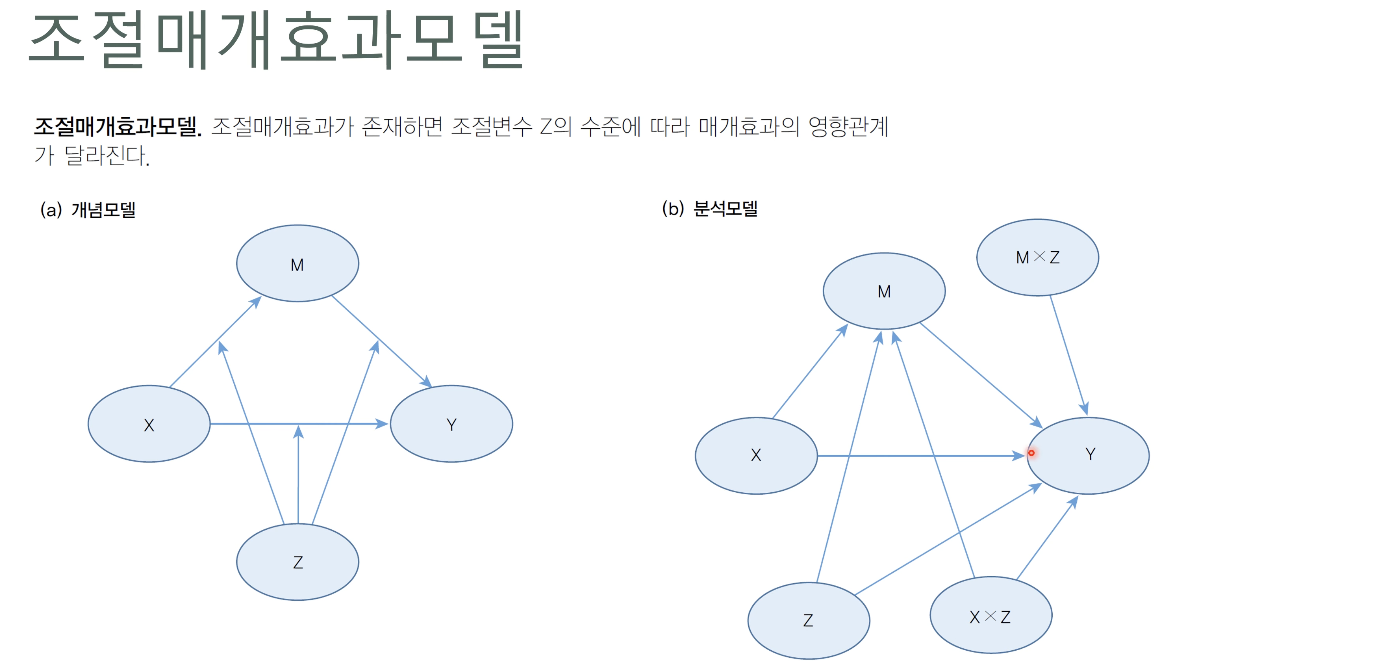
- X -> M 간의 영향관계에서 조절변수 Z의 역할을 보고 싶을 때 X*Z 항을 모델에 추가한다.
- M -> Y 간의 영향관계에서 조절변수 Z의 역할을 알고 싶을때 M*Z 항을 모델에 추가한다.

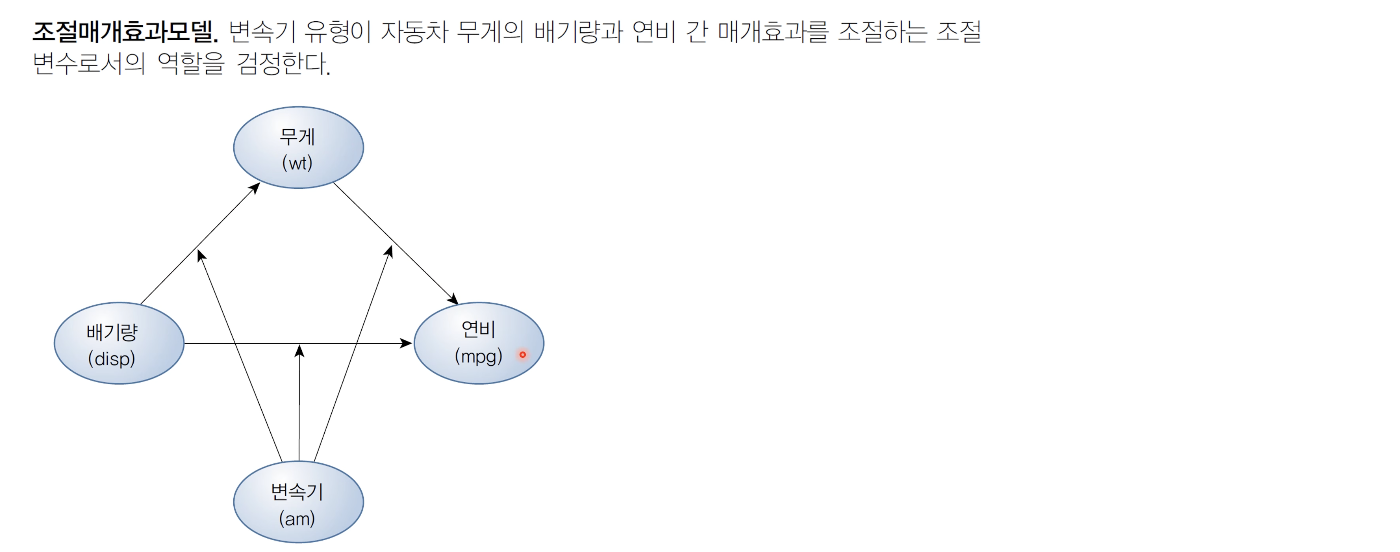
- 배기량, 무게, 연비 변수에서 제 4의 변수 변속기의 유형(수동/자동)에 따라 매개효과가 달라지는지 알고 싶을때

In [31]:
import statsmodels.api as sm

# mtcars 데이터 불러오기
mtcars = sm.datasets.get_rdataset("mtcars", package="datasets").data

mtcars.head()

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
rownames,,,,,,,,,,,
Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


In [35]:
# X -> M에 조절효과(상호작용항) 추가 
model_M = smf.ols("wt ~ disp*am", data=mtcars).fit()

In [36]:
# X, M -> Y 에 조절효과 추가
model_Y = smf.ols("mpg ~ disp*am + wt*am", data=mtcars).fit()

In [37]:
def _coef(m, name):
    """이름이 없으면 0 반환(상호작용 항이 모형에 없을 때 대비)."""
    return m.params[name] if name in m.params.index else 0.0

def effects_at_am(am_level, mM, mY):
    """
    am이 0 또는 1로 고정됐을 때의 파라메트릭 효과 계산
    - a_path(am): ∂E[wt]/∂disp = b_disp + b_disp:am * am
    - b_path(am): ∂E[mpg]/∂wt  = c_wt  + c_wt:am  * am
    - direct(am): ∂E[mpg]/∂disp (wt 고정) = c_disp + c_disp:am * am
    """
    a  = _coef(mM, "disp") + am_level * _coef(mM, "disp:am")
    b  = _coef(mY, "wt")   + am_level * _coef(mY, "wt:am")
    de = _coef(mY, "disp") + am_level * _coef(mY, "disp:am")  # ADE
    acme  = a * b
    ade   = de
    total = acme + ade
    return {"ACME": acme, "ADE": ade, "Total": total, "a": a, "b": b}

# 3) 부트스트랩으로 CI, p-value 계산 (퍼센타일 CI, 양측 p-value)
def med_bootstrap(df, sims=500, seed=12):
    rng = np.random.default_rng(seed)
    n = len(df)

    # 모수추정(원표본) 먼저
    base = {
        0: effects_at_am(0, model_M, model_Y),
        1: effects_at_am(1, model_M, model_Y),
    }

    # 부트스트랩 분포 저장
    boot = {0: {"ACME": [], "ADE": [], "Total": []},
            1: {"ACME": [], "ADE": [], "Total": []}}

    for _ in range(sims):
        idx = rng.integers(0, n, size=n)
        bdf = df.iloc[idx].copy()
        bdf["am"] = bdf["am"].astype(int)

        mM_b = smf.ols("wt ~ disp * am", data=bdf).fit()
        mY_b = smf.ols("mpg ~ disp * am + wt * am", data=bdf).fit()

        for am_level in (0, 1):
            eff = effects_at_am(am_level, mM_b, mY_b)
            for key in ("ACME", "ADE", "Total"):
                boot[am_level][key].append(eff[key])

    # 요약표 만들기
    out_rows = []
    for am_level in (0, 1):
        for key in ("ACME", "ADE", "Total"):
            est = base[am_level][key]
            dist = np.array(boot[am_level][key])
            lo, hi = np.percentile(dist, [2.5, 97.5])

            # 양측 p-value (퍼센타일 분포 기준, 중심 0 가정)
            # 관측치의 절대값보다 더 극단적인 비율 ×2
            p = (np.mean(np.abs(dist) >= np.abs(est)) * 2).clip(0, 1)

            out_rows.append({
                "am": am_level,
                "Effect": key,
                "Estimate": est,
                "CI 2.5%": lo,
                "CI 97.5%": hi,
                "p-value": p
            })

        # 비중(Prop. mediated) = ACME / Total
        prop_est = base[am_level]["ACME"] / base[am_level]["Total"] if base[am_level]["Total"] != 0 else np.nan
        # 부트스트랩 분포에서의 비중
        prop_dist = np.array(boot[am_level]["ACME"]) / np.array(boot[am_level]["Total"])
        prop_lo, prop_hi = np.percentile(prop_dist, [2.5, 97.5])
        prop_p = (np.mean(np.abs(prop_dist) >= np.abs(prop_est)) * 2).clip(0, 1)

        out_rows.append({
            "am": am_level,
            "Effect": "Prop. Mediated",
            "Estimate": prop_est,
            "CI 2.5%": prop_lo,
            "CI 97.5%": prop_hi,
            "p-value": prop_p
        })

    return pd.DataFrame(out_rows)

# 4) 실행 (R 코드의 sims=500, seed=12와 동일)
res = med_bootstrap(mtcars, sims=500, seed=12) # 부트스트랩핑
print(res.round(4))

   am          Effect  Estimate  CI 2.5%  CI 97.5%  p-value
0   0            ACME   -0.0103  -0.0244    0.0059    1.000
1   0             ADE   -0.0173  -0.0379    0.0001    0.856
2   0           Total   -0.0276  -0.0361   -0.0164    0.972
3   0  Prop. Mediated    0.3719  -0.2177    0.9566    1.000
4   1            ACME   -0.0408  -0.0894   -0.0128    0.932
5   1             ADE   -0.0182  -0.1284    0.0057    0.940
6   1           Total   -0.0590  -0.1561   -0.0411    0.980
7   1  Prop. Mediated    0.6916   0.1095    1.0918    1.000


In [38]:
# am = 0 : 자동 변속기 유형
# 간접효과 ACME : -0.0103
# am = 1 : 수동 변속기 유형 
# 간접효과 ACME : -0.0408

# 수동 변속기가 자동변속기 유형보다 간접효과 크기가 더 크다. 
# 자동 변속기에서 간접효과가 통계적으로 유의하지 않다. 따라서 수동변속기가 자동변속기가 간접효과가 더 크고, 통계적으로 유의하다.
# 수동 변속기와 자동 변속기의 간접효과 차이가 통계적으로 유의한지 검정해야한다. 

In [41]:
def coef_or0(m, name):
    return m.params[name] if name in m.params.index else 0.0

def cond_effects(am_val, mM, mY):
    """조건부 효과 (ACME, ADE, Total)"""
    a = coef_or0(mM, "disp") + am_val * coef_or0(mM, "disp:am")
    b = coef_or0(mY, "wt")   + am_val * coef_or0(mY, "wt:am")
    ade = coef_or0(mY, "disp") + am_val * coef_or0(mY, "disp:am")
    acme = a * b
    total = acme + ade
    return {"ACME": acme, "ADE": ade, "Total": total}

# 원본 데이터에서 효과
eff0 = cond_effects(0, model_M, model_Y)   # am=0
eff1 = cond_effects(1, model_M, model_Y)   # am=1
print("Effects at am=0:", eff0)
print("Effects at am=1:", eff1)

Effects at am=0: {'ACME': -0.010257036715495797, 'ADE': -0.01732655955500882, 'Total': -0.027583596270504614}
Effects at am=1: {'ACME': -0.040829954365477795, 'ADE': -0.018208462282556476, 'Total': -0.059038416648034275}


In [42]:
# 2) 부트스트랩으로 CI 및 두 조건 차이 검정
def bootstrap_diff(df, sims=500, seed=12):
    rng = np.random.default_rng(seed)
    n = len(df)
    boot0, boot1 = [], []
    for _ in range(sims):
        samp = df.sample(n, replace=True, random_state=rng.integers(1e9))
        mM_b = smf.ols("wt ~ disp * am", data=samp).fit()
        mY_b = smf.ols("mpg ~ disp * am + wt * am", data=samp).fit()
        boot0.append(cond_effects(0, mM_b, mY_b))
        boot1.append(cond_effects(1, mM_b, mY_b))
    boot0, boot1 = pd.DataFrame(boot0), pd.DataFrame(boot1)

    results = []
    for key in ["ACME", "ADE", "Total"]:
        diff = boot1[key] - boot0[key]
        est = diff.mean()
        lo, hi = np.percentile(diff, [2.5, 97.5])
        pval = (np.mean(np.abs(diff) >= np.abs(est)) * 2).clip(0, 1)
        results.append({"Effect": key,
                        "Diff (am=1 - am=0)": est,
                        "95% CI low": lo,
                        "95% CI high": hi,
                        "p-value": pval})
    return pd.DataFrame(results)

res = bootstrap_diff(mtcars, sims=500, seed=12)
print("\nConditional mediation difference (am=1 vs am=0):")
print(res.round(4))


Conditional mediation difference (am=1 vs am=0):
  Effect  Diff (am=1 - am=0)  95% CI low  95% CI high  p-value
0   ACME             -0.0338     -0.0818      -0.0024    0.848
1    ADE             -0.0089     -0.1079       0.0325    1.000
2  Total             -0.0426     -0.1324      -0.0103    0.568


1. ACME : 간접효과의 차이를 검정 
    - 배기량이 무게를 매개로 해서 연비에 미치는 영향의 차이를 검정
    - 유의하지 않다.
2. ADE : 직접효과의 차이를 검정
    - 배기량이 연비에 미치는 직접효과의 차이를 검정 
    - 유의하지 않다.

# 지수예측모델 (Exponential Smoothing Model) 이란?

In [6]:
# 시계열 분석에서 미래를 예측하기 위해 사용되는 대표적인 방법 중 하나
# 과거 데이터에 지수적으로 가중치를 두고 평균을 내서 예측값을 만든다고 해서 지수평활법 (exponential smoothing) 이라고 불려.
# 특히 단기 예측에서 성능이 뛰어난 걸로 잘 알려져 있어.

# !pip install statsmodels

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# 예제 데이터: 항공 승객 수
from statsmodels.datasets import get_rdataset
airpassengers = get_rdataset("AirPassengers", package="datasets").data
airpassengers['time'] = pd.date_range(start='1949-01', periods=len(airpassengers), freq='M')
airpassengers = airpassengers.set_index('time')
ts = airpassengers['value']

/Users/sin-yuwon/test/.venv/lib/python3.7/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency M will be used.
  self._init_dates(dates, freq)


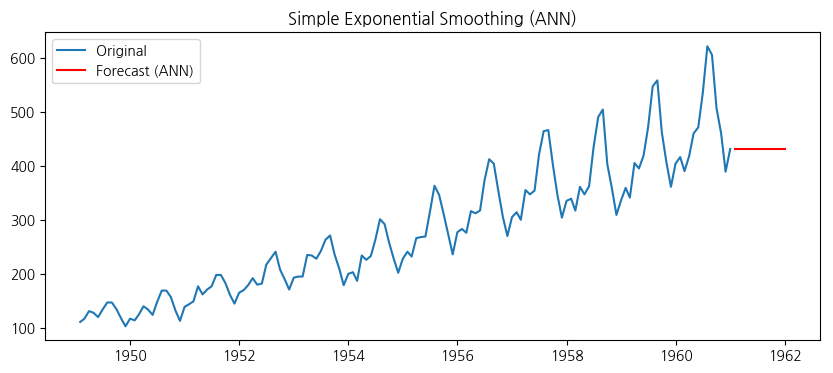

In [7]:
# 단순지수평활법 (Simple Exponential Smoothing / ANN)
# 수준(평균)만 고려, 추세와 계절성 없음
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

model_ann = SimpleExpSmoothing(ts).fit()
forecast_ann = model_ann.forecast(12)

# 시각화
plt.figure(figsize=(10,4))
plt.plot(ts, label='Original')
plt.plot(forecast_ann, label='Forecast (ANN)', color='red')
plt.title('Simple Exponential Smoothing (ANN)')
plt.legend()
plt.show()

/Users/sin-yuwon/test/.venv/lib/python3.7/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency M will be used.
  self._init_dates(dates, freq)


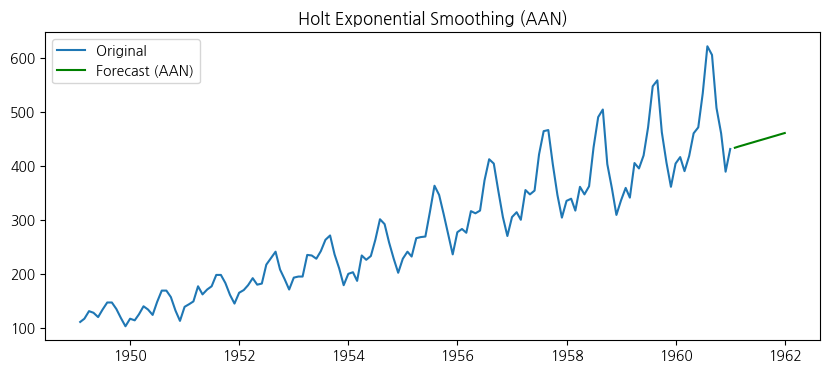

In [8]:
# Holt’s 지수평활법 (수준 + 추세 / AAN)

from statsmodels.tsa.holtwinters import Holt

model_aan = Holt(ts).fit()
forecast_aan = model_aan.forecast(12)

plt.figure(figsize=(10,4))
plt.plot(ts, label='Original')
plt.plot(forecast_aan, label='Forecast (AAN)', color='green')
plt.title('Holt Exponential Smoothing (AAN)')
plt.legend()
plt.show()

/Users/sin-yuwon/test/.venv/lib/python3.7/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency M will be used.
  self._init_dates(dates, freq)


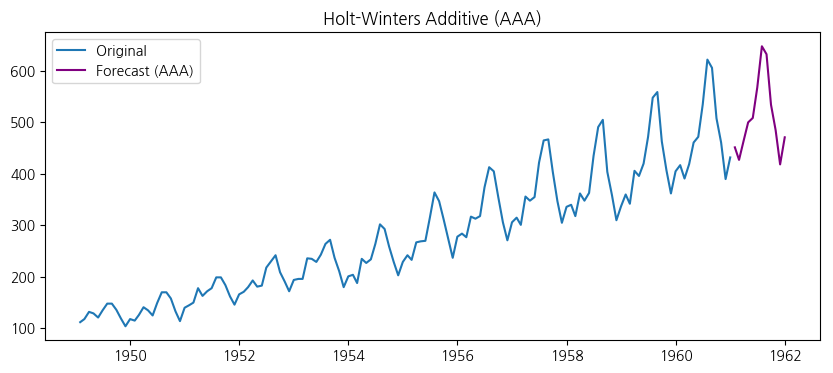

In [9]:
# Holt-Winters 지수평활법 (수준 + 추세 + 계절성 / AAA, AAM, MAM 등)

model_aaa = ExponentialSmoothing(ts,
                                  trend='add',
                                  seasonal='add',
                                  seasonal_periods=12).fit()
forecast_aaa = model_aaa.forecast(12)

plt.figure(figsize=(10,4))
plt.plot(ts, label='Original')
plt.plot(forecast_aaa, label='Forecast (AAA)', color='purple')
plt.title('Holt-Winters Additive (AAA)')
plt.legend()
plt.show()

/Users/sin-yuwon/test/.venv/lib/python3.7/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency M will be used.
  self._init_dates(dates, freq)


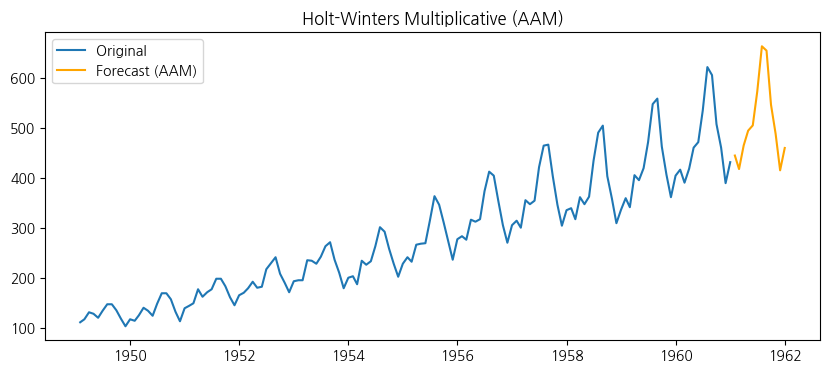

In [10]:
# Multiplicative 계절성 포함 (AAM)

model_aam = ExponentialSmoothing(ts,
                                  trend='add',
                                  seasonal='mul',
                                  seasonal_periods=12).fit()
forecast_aam = model_aam.forecast(12)

plt.figure(figsize=(10,4))
plt.plot(ts, label='Original')
plt.plot(forecast_aam, label='Forecast (AAM)', color='orange')
plt.title('Holt-Winters Multiplicative (AAM)')
plt.legend()
plt.show()

/Users/sin-yuwon/test/.venv/lib/python3.7/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency M will be used.
  self._init_dates(dates, freq)
/Users/sin-yuwon/test/.venv/lib/python3.7/site-packages/statsmodels/tsa/holtwinters/model.py:83: RuntimeWarning: overflow encountered in matmul
  return err.T @ err


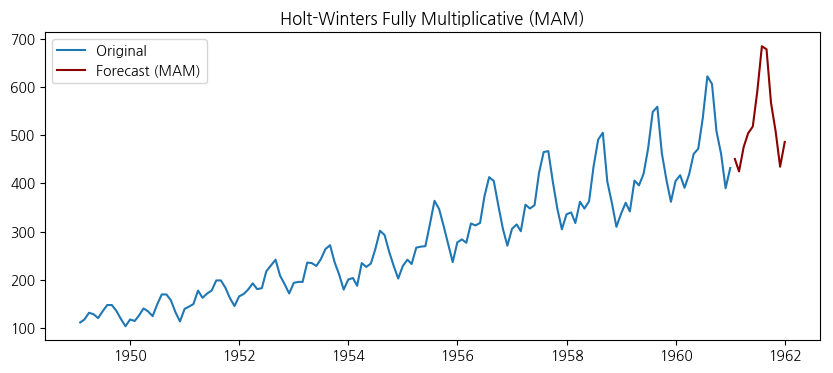

In [11]:
# 완전 곱셈형 (MAM)

model_mam = ExponentialSmoothing(ts,
                                  trend='mul',
                                  seasonal='mul',
                                  seasonal_periods=12).fit()
forecast_mam = model_mam.forecast(12)

plt.figure(figsize=(10,4))
plt.plot(ts, label='Original')
plt.plot(forecast_mam, label='Forecast (MAM)', color='darkred')
plt.title('Holt-Winters Fully Multiplicative (MAM)')
plt.legend()
plt.show()

In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# 평가 구간 설정 (예측 구간과 동일하게 마지막 12개월을 평가)
train = ts[:-12]
test = ts[-12:]

# 모델별 예측
ann = SimpleExpSmoothing(train).fit().forecast(12)
aan = Holt(train).fit().forecast(12)
aaa = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=12).fit().forecast(12)
aam = ExponentialSmoothing(train, trend='add', seasonal='mul', seasonal_periods=12).fit().forecast(12)
mam = ExponentialSmoothing(train, trend='mul', seasonal='mul', seasonal_periods=12).fit().forecast(12)

# 오차 계산 함수
def calculate_errors(true, pred):
    mae = mean_absolute_error(true, pred)
    mse = mean_squared_error(true, pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(true, pred)
    return [mae, mse, rmse, mape]

# 모든 결과 저장
results = {
    'ANN': calculate_errors(test, ann),
    'AAN': calculate_errors(test, aan),
    'AAA': calculate_errors(test, aaa),
    'AAM': calculate_errors(test, aam),
    'MAM': calculate_errors(test, mam)
}

# 결과 출력
error_df = pd.DataFrame(results, index=['MAE', 'MSE', 'RMSE', 'MAPE (%)']).T
import seaborn as sns
import matplotlib.pyplot as plt

print(error_df.round(2))

/Users/sin-yuwon/test/.venv/lib/python3.7/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency M will be used.
  self._init_dates(dates, freq)
/Users/sin-yuwon/test/.venv/lib/python3.7/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency M will be used.
  self._init_dates(dates, freq)
/Users/sin-yuwon/test/.venv/lib/python3.7/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency M will be used.
  self._init_dates(dates, freq)
/Users/sin-yuwon/test/.venv/lib/python3.7/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency M will be used.
  self._init_dates(dates, freq)
/Users/sin-yuwon/test/.venv/lib/python3.7/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency inform

       MAE       MSE    RMSE  MAPE (%)
ANN  76.14  10634.65  103.12     14.28
AAN  68.08   8913.36   94.41     12.75
AAA  13.38    288.31   16.98      2.80
AAM  10.30    249.96   15.81      2.21
MAM  20.85    666.14   25.81      4.33


# 요인분석, 타당도 분석, 집중타당도(convergent validity), 판별타당도(discriminant validity), 측정타당도
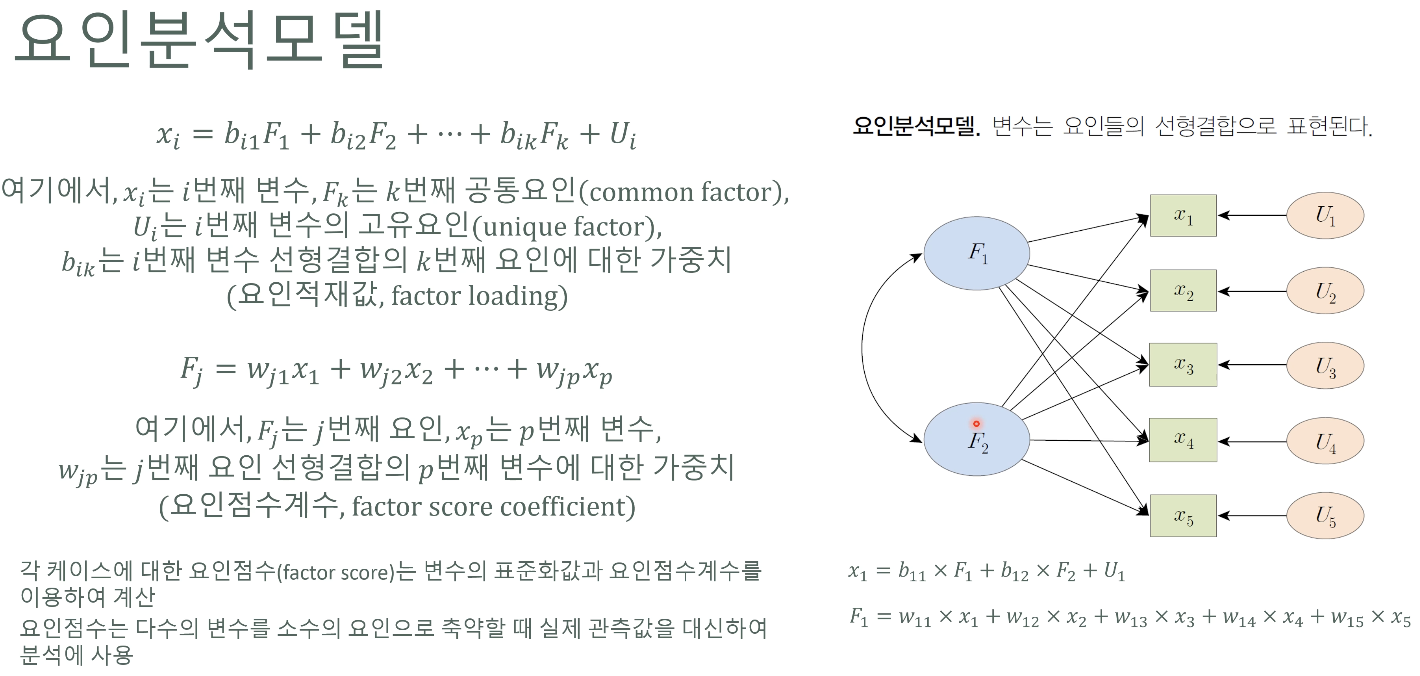

- F1, F2 잠재 요인 
- 실제 독립변수 
- U_i 는 오차항

**요인분석에서 중요한 것 : 요인개수 결정하기**
- 데이터의 복잡성을 줄이면서 해석가능한 요인을 추출하는 것이 주요목적
- 가능한 많은 분산을 설명하는 최소한의 요인 개수를 결정한다.
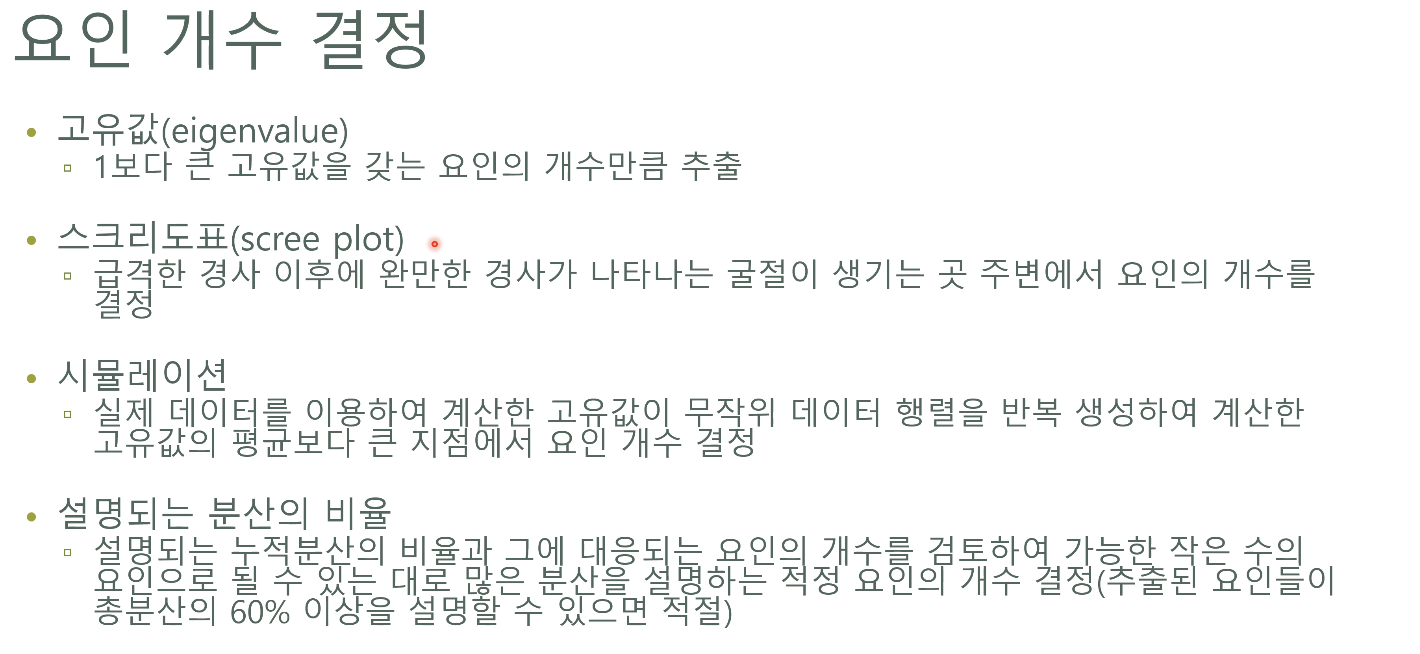

In [44]:
!pip install factor-analyzer

In [47]:
import statsmodels.api as sm
from factor_analyzer import FactorAnalyzer

olympic = pd.read_csv("olympic.csv")
olympic

,100,long,poid,haut,400,110,disq,perc,jave,1500
0,11.25,7.43,15.48,2.27,48.90,15.13,49.28,4.7,61.32,268.95
1,10.87,7.45,14.97,1.97,47.71,14.46,44.36,5.1,61.76,273.02
2,11.18,7.44,14.20,1.97,48.29,14.81,43.66,5.2,64.16,263.20
3,10.62,7.38,15.02,2.03,49.06,14.72,44.80,4.9,64.04,285.11
4,11.02,7.43,12.92,1.97,47.44,14.40,41.20,5.2,57.46,256.64
5,10.83,7.72,13.58,2.12,48.34,14.18,43.06,4.9,52.18,274.07
6,11.18,7.05,14.12,2.06,49.34,14.39,41.68,5.7,61.60,291.20
7,11.05,6.95,15.34,2.00,48.21,14.36,41.32,4.8,63.00,265.86
8,11.15,7.12,14.52,2.03,49.15,14.66,42.36,4.9,66.46,269.62
9,11.23,7.28,15.25,1.97,48.60,14.76,48.02,5.2,59.48,292.24


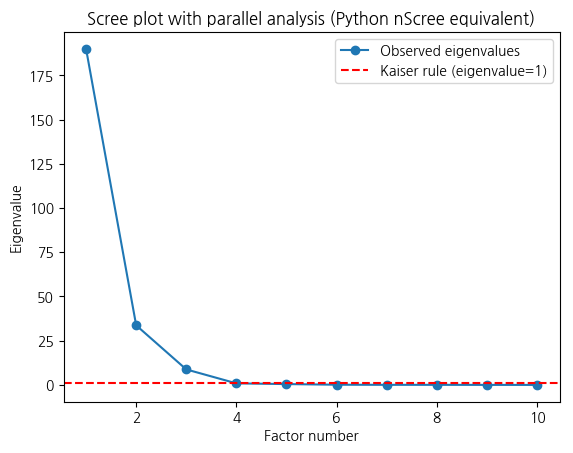

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.decomposition import PCA

# 1) 데이터 준비 (olympic 데이터 불러오기)
X = olympic.select_dtypes(include=[np.number]).dropna().values

# 2) 관측 데이터의 고유값 (PCA로 얻음)
pca = PCA()
pca.fit(X)
eigvals_obs = pca.explained_variance_

# 4) nScree 스타일 그래프
plt.plot(range(1, len(eigvals_obs)+1), eigvals_obs, marker='o', label="Observed eigenvalues")
plt.axhline(1, color='red', linestyle='--', label="Kaiser rule (eigenvalue=1)")
plt.xlabel("Factor number")
plt.ylabel("Eigenvalue")
plt.title("Scree plot with parallel analysis (Python nScree equivalent)")
plt.legend()
plt.show()

In [51]:
# 1보다 큰 고유값을 갖는 기준에 따르면 2~3개의 요인을 선택하는 것이 좋다.

In [55]:
# 3) 상관행렬
corr = np.corrcoef(X.T)

# 4) 고유값 분해
eigvals, eigvecs = np.linalg.eig(corr)

print("Eigenvalues:\n")
eigvals
# 1보다 큰 고유값 : 초반 2개 

Eigenvalues:



array([3.41823814, 2.60639314, 0.94329641, 0.87802124, 0.10185415,
       0.26694941, 0.30679812, 0.55662665, 0.43059522, 0.49122752])

In [61]:
import statsmodels.api as sm
from factor_analyzer import FactorAnalyzer

X = olympic.select_dtypes(include=[np.number]).dropna()

# 2) 요인분석 (최대우도 ML, 요인=2)
fa = FactorAnalyzer(n_factors=2, method='ml', rotation=None)
fa.fit(X)

# 3) 결과 출력
print("Loadings (요인적재행렬):")
print(pd.DataFrame(fa.loadings_, index=X.columns, columns=["Factor1", "Factor2"]))

print("\nUniquenesses (특수요인분산):")
print(pd.Series(fa.get_uniquenesses(), index=X.columns))

print("\nVariance explained (요인별 설명분산):")
variance = fa.get_factor_variance()
print("SS Loadings:", variance[0])
print("Proportion Var:", variance[1])
print("Cumulative Var:", variance[2])

# 4) 회귀 요인점수 (scores="regression")
factor_scores = fa.transform(X)
print("\nFactor scores (첫 5행):")
print(pd.DataFrame(factor_scores, columns=["Factor1", "Factor2"]).head())

Loadings (요인적재행렬):
       Factor1   Factor2
100   0.745404 -0.219694
long -0.655284  0.155240
poid  0.013561  0.988702
haut -0.221259  0.134863
400   0.840131  0.083490
110   0.696631 -0.308509
disq  0.148059  0.812632
perc -0.426734  0.493226
jave  0.053631  0.599181
1500  0.542906  0.273166

Uniquenesses (특수요인분산):
100     0.396108
long    0.546504
poid    0.022284
haut    0.932857
400     0.287209
110     0.419528
disq    0.317707
perc    0.574626
jave    0.638106
1500    0.630633
dtype: float64

Variance explained (요인별 설명분산):
SS Loadings: [2.72692538 2.50751359]
Proportion Var: [0.27269254 0.25075136]
Cumulative Var: [0.27269254 0.5234439 ]

Factor scores (첫 5행):
    Factor1   Factor2
0 -0.133977  1.156551
1 -1.341955  0.778123
2 -0.825608  0.215964
3 -0.808809  0.837062
4 -1.650895 -0.725719


In [ ]:
# Loadings : 요인 적재값 
# 요인과 변수간의 관계를 보여줌
# Uniquenesses: 고유요인에 의해 출력되는 분산

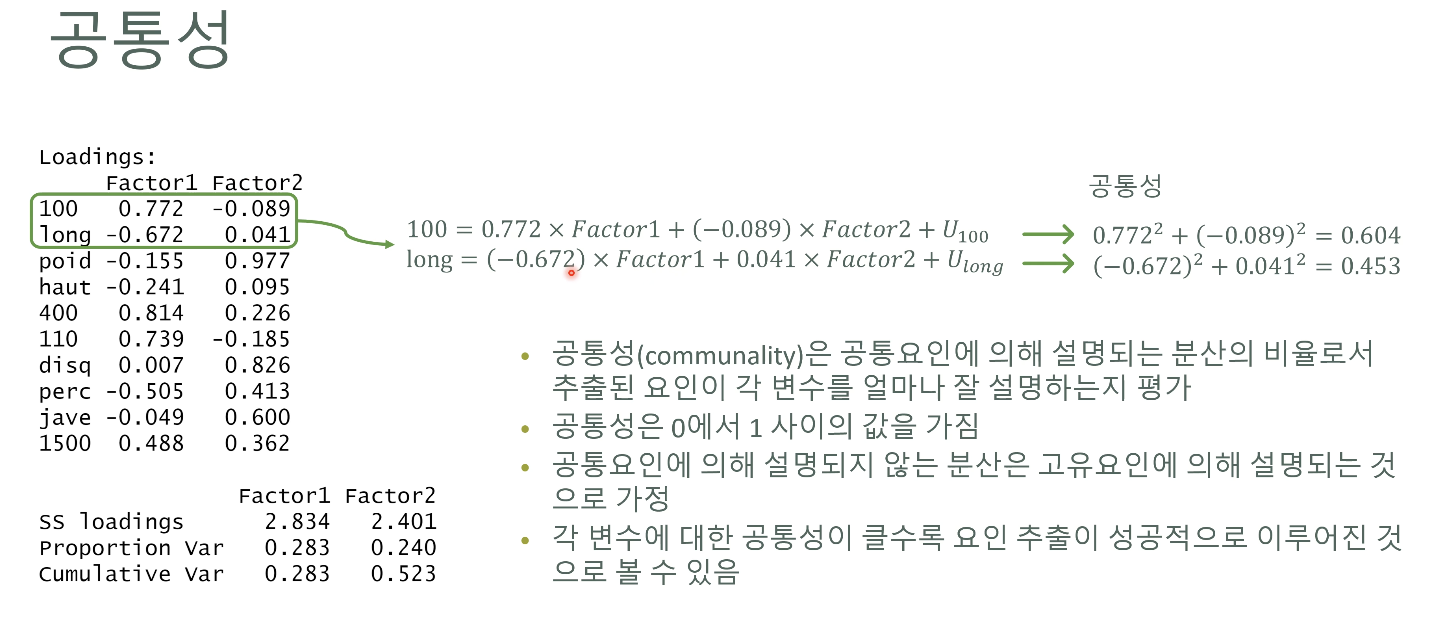

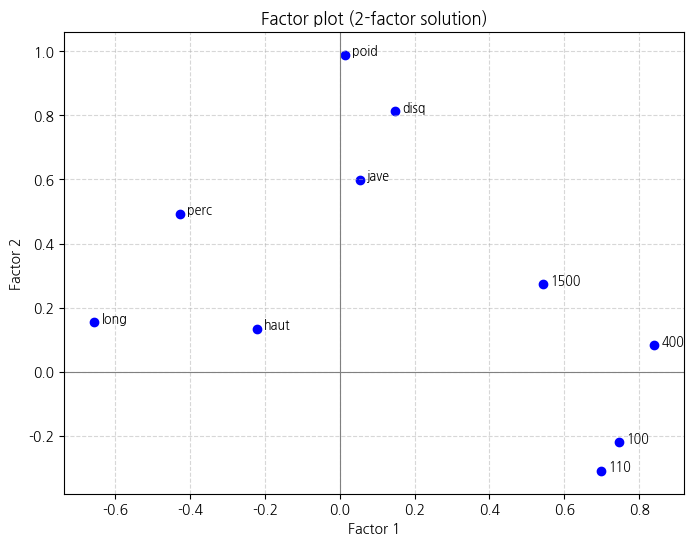

In [64]:
# 3) 요인적재행렬
loadings = pd.DataFrame(fa.loadings_, 
                        index=X.columns, 
                        columns=["Factor1", "Factor2"])

# 4) 플롯
plt.figure(figsize=(8, 6))
plt.axhline(0, color='grey', linewidth=0.8)
plt.axvline(0, color='grey', linewidth=0.8)

plt.scatter(loadings["Factor1"], loadings["Factor2"], c="blue")

# 각 변수 이름 추가 (labels=colnames, pos=4)
for i, var in enumerate(loadings.index):
    plt.text(loadings["Factor1"][i] + 0.02,  # pos=4 → 오른쪽에 표시
             loadings["Factor2"][i], 
             var, fontsize=9, color="black")

plt.xlabel("Factor 1")
plt.ylabel("Factor 2")
plt.title("Factor plot (2-factor solution)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

1) Bartlett의 구형성 검정
	•	p < 0.05 → 요인분석 적합

2) KMO 검정
	•	0.6 이상이면 요인분석 적절

3) 요인적재량
	•	특정 문항이 어느 요인에 강하게 적재되었는지 확인
	•	0.5 이상이면 집중타당도 확보 가능

4) AVE
	•	각 요인의 평균 분산 추출 값
	•	0.5 이상이면 집중타당도 확보
